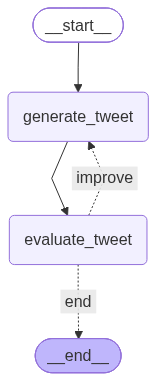


FINAL RESULT 

Topic: Artificial Intelligence

Final Tweet:
**"AI isn’t just smarter—it’s rewriting the rules of creativity, work, and even how we think. The question isn’t *if* it’s here… but how we’ll use it."**

Feedback:
APPROVED

Total Iterations:
1

Approved:
True


In [1]:

from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

load_dotenv()

llm = ChatMistralAI(model="ministral-3b-latest")

class State(TypedDict):
    topic: str
    tweet: str
    feedback: str
    iteration: int
    approved: bool

def generate_tweet(state: State):
    prompt = f"""
    You are a professional social media content creator.
    Topic: {state['topic']}
    Previous Tweet:
    {state.get('tweet', 'None')}
    Feedback:
    {state.get('feedback', 'None')}
    Generate a short, engaging tweet about the topic.
    Requirements:
    - Keep it under 280 characters.
    - Make it clear and engaging.
    - Avoid unnecessary words.
    - Return only the tweet.
    """
    response = llm.invoke(prompt)
    return {
        "tweet": response.content.strip(),
        "iteration": state["iteration"] + 1
    }

def evaluate_tweet(state: State):
    prompt = f"""
    You are a tweet quality evaluator.
    Topic: {state['topic']}
    Tweet:
    {state['tweet']}
    Evaluate this tweet based on:
    1. Clarity
    2. Engagement
    3. Relevance to the topic
    4. Maximum 280 characters
    If the tweet meets the criteria, respond exactly:
    APPROVED
    Otherwise, respond in this format:
    IMPROVE: <specific feedback>
    """
    response = llm.invoke(prompt)

    evaluation = response.content.strip()

    if evaluation.upper().startswith("APPROVED"):
        return {
            "approved": True,
            "feedback": evaluation
        }

    return {
        "approved": False,
        "feedback": evaluation
    }

def route_tweet(state: State) -> Literal["end", "improve"]:
    # Stop if the tweet is approved
    if state["approved"]:
        return "end"

    # Stop after maximum iterations
    if state["iteration"] >= 3:
        return "end"

    # Otherwise, improve the tweet
    return "improve"

graph = StateGraph(State)

graph.add_node("generate_tweet", generate_tweet)
graph.add_node("evaluate_tweet", evaluate_tweet)

# START → Generate Tweet
graph.add_edge(START, "generate_tweet")

# Generate Tweet → Evaluate Tweet
graph.add_edge("generate_tweet", "evaluate_tweet")

# Conditional Routing
graph.add_conditional_edges(
    "evaluate_tweet",
    route_tweet,
    {
        "end": END,
        "improve": "generate_tweet"
    }
)

workflow = graph.compile()

from IPython.display import Image, display
# Generate and display the workflow graph
display(Image(workflow.get_graph().draw_mermaid_png()))
    
result = workflow.invoke({
    "topic": "Artificial Intelligence",
    "tweet": "",
    "feedback": "",
    "iteration": 0,
    "approved": False
})

print("\nFINAL RESULT \n")

print("Topic:", result["topic"])

print("\nFinal Tweet:")
print(result["tweet"])

print("\nFeedback:")
print(result["feedback"])

print("\nTotal Iterations:")
print(result["iteration"])

print("\nApproved:")
print(result["approved"])